# 09 — Robustez al Ruido Gaussiano: Análisis SNR del ICD (Punto 4)

**Objetivo:** Evaluar qué tan robusto es el ICD ante ruido de medición gaussiano aditivo (AWGN),
simulando condiciones reales de monitoreo en plataformas offshore.

**Metodología:**
1. Ruido AWGN inyectado directamente sobre el valor ICD: $\text{ICD}^{\text{noisy}} = \text{ICD} + \varepsilon$, $\varepsilon \sim \mathcal{N}(0, \sigma_{\text{noise}}^2)$
2. Nivel de ruido controlado por SNR: $\sigma_{\text{noise}} = \sigma_{\text{ICD}} / 10^{\text{SNR}_{dB}/20}$
3. Binarización con umbral = mediana(ICD limpio): detección = (ICD_noisy ≥ umbral)
4. Estimación Monte Carlo (N_MC=500) para estabilizar la POD promedio
5. Barrido SNR: [∞, 40, 30, 20, 15, 10, 5] dB

**Resultados esperados:**
- Familia de curvas POD por nivel de SNR
- Curva de degradación AUC-POD vs SNR (figura para el paper)
- SNR crítico: nivel mínimo para mantener AUC-POD ≥ 0.80
- Tabla LaTeX: SNR × tipo de elemento × AUC-POD

**Referencias metodológicas:**
- Doebling et al. (1998) — requisito mínimo de evaluación bajo ruido para DIs
- Worden & Dulieu-Barton (2004) — AWGN como modelo estándar de ruido en SHM
- Figueiredo et al. (2011) — estimación Monte Carlo de POD bajo ruido

**Punto 4 de los 6 mínimos para AOR:**
> *Robustez al ruido: demostrar que el ICD mantiene alta POD bajo condiciones realistas de SNR.*

## 1. Librerías y Configuración

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
})
%matplotlib inline

# Semilla para reproducibilidad
SEED = 42
rng  = np.random.default_rng(SEED)

# Parámetros del análisis Monte Carlo
N_MC = 500   # repeticiones por nivel de SNR

# Niveles de SNR a evaluar (dB)
# np.inf = sin ruido (baseline), luego degradación progresiva
SNR_LEVELS_DB = [np.inf, 40, 30, 20, 15, 10, 5]
SNR_LABELS    = ['Clean', '40 dB', '30 dB', '20 dB', '15 dB', '10 dB', '5 dB']

print(f'✓ Librerías cargadas')
print(f'  N_MC = {N_MC} iteraciones Monte Carlo')
print(f'  SNR levels: {SNR_LABELS}')

✓ Librerías cargadas
  N_MC = 500 iteraciones Monte Carlo
  SNR levels: ['Clean', '40 dB', '30 dB', '20 dB', '15 dB', '10 dB', '5 dB']


## 2. Rutas y Datos

In [3]:
base_path         = Path.home() / 'github' / 'Proyecto-doctoral'
resultados_nuevos = base_path / 'outputs' / 'resultados_nuevos'
tablas_dir        = base_path / 'manuscript_AOR' / 'tablas'
tablas_dir.mkdir(parents=True, exist_ok=True)

FUENTES = {
    'Denting': resultados_nuevos / 'abolladuras_2026' / 'todos_los_resultados_con_ICD_abolladura.xlsx',
    'Corrosion': resultados_nuevos / 'corrosion_2026'  / 'todos_los_resultados_con_ICD_corrosion.xlsx',
}

ELEM_COLORS  = {'Brace': '#E74C3C', 'Inclined_leg': '#2980B9', 'Beam': '#27AE60'}
ELEM_MARKERS = {'Brace': 'o', 'Inclined_leg': 's', 'Beam': '^'}

for name, path in FUENTES.items():
    print(f"{'✓' if path.exists() else '✗'} {name}: {path.name}")

✓ Denting: todos_los_resultados_con_ICD_abolladura.xlsx
✓ Corrosion: todos_los_resultados_con_ICD_corrosion.xlsx


## 3. Cargar Datos

In [4]:
dfs = {}
for damage_type, path in FUENTES.items():
    df = pd.read_excel(path)
    df['member_type'] = df['Tipo_elemento_a_buscar'].str.strip()
    dfs[damage_type] = df
    print(f'{damage_type}: {len(df):,} filas')
    print(f'  ICD range: [{df["ICD"].min():.4f}, {df["ICD"].max():.4f}]  '
          f'mean={df["ICD"].mean():.4f}  std={df["ICD"].std():.4f}')
    print(f'  DeteccionOK_binario: {df["DeteccionOK_binario"].value_counts().to_dict()}')

print()
print('Columnas disponibles (no-alpha):', [c for c in dfs['Denting'].columns
                                            if 'alpha' not in c.lower()])

Denting: 1,080 filas
  ICD range: [0.0000, 1.0000]  mean=0.4543  std=0.3046
  DeteccionOK_binario: {1: 996, 0: 84}
Corrosion: 2,160 filas
  ICD range: [0.0000, 1.0000]  mean=0.5156  std=0.2824
  DeteccionOK_binario: {1: 2084, 0: 76}

Columnas disponibles (no-alpha): ['ID', 'Elemento', 'Porcentaje', 'Tiempo_s', 'ObjFinal', 'DeteccionOK', 'N_FalsosPositivos', 'MAC_minimo', 'MAC_promedio', 'Hubo_cruces_modales', 'C_norm', 'P_FP', 'ICD', 'Tipo_elemento_a_buscar', 'DeteccionOK_binario', 'member_type']


## 4. Funciones: Inyección de Ruido AWGN y POD

### Modelo de ruido
$$\text{ICD}^{\text{noisy}} = \text{ICD}^{\text{clean}} + \varepsilon, \quad \varepsilon \sim \mathcal{N}(0, \sigma_{\text{noise}}^2)$$
$$\sigma_{\text{noise}} = \frac{\sigma_{\text{ICD}}}{10^{\text{SNR}_{dB}/20}}$$

El resultado se recorta al intervalo [0, 1] ya que ICD ∈ [0, 1] por diseño.

### Umbral de detección
Se usa la **mediana del ICD limpio** como umbral fijo — calibrado en condiciones sin ruido
y aplicado igual bajo todas las condiciones de ruido (escenario conservador).

### Monte Carlo
Para cada nivel de SNR se repiten N_MC realizaciones independientes del ruido y se
promedia la POD resultante, eliminando la varianza de una sola realización.

In [7]:

# ── Métricas (sin sklearn — PyPy compatible) ────────────────────────────────

def roc_auc_score(y_true, y_score):
    """AUC-ROC manual via Mann-Whitney U (idéntico a sklearn)."""
    y_true  = np.asarray(y_true,  dtype=int)
    y_score = np.asarray(y_score, dtype=float)
    n_pos = y_true.sum()
    n_neg = len(y_true) - n_pos
    if n_pos == 0 or n_neg == 0:
        return np.nan
    order = np.argsort(y_score)
    ranks = np.empty(len(y_score), dtype=float)
    ranks[order] = np.arange(1, len(y_score) + 1)
    unique_scores, inv = np.unique(y_score, return_inverse=True)
    for i in range(len(unique_scores)):
        mask = inv == i
        ranks[mask] = ranks[mask].mean()
    return (ranks[y_true == 1].sum() - n_pos * (n_pos + 1) / 2) / (n_pos * n_neg)


# ── Inyección de ruido AWGN ──────────────────────────────────────────────────

def inject_awgn(icd_values, snr_db, sigma_signal, rng_local):
    """
    Inyecta ruido AWGN sobre valores ICD.
    snr_db = np.inf → sin ruido. Resultado recortado a [0, 1].
    """
    if np.isinf(snr_db):
        return icd_values.copy()
    sigma_noise = sigma_signal / (10 ** (snr_db / 20.0))
    return np.clip(icd_values + rng_local.normal(0, sigma_noise, size=len(icd_values)), 0.0, 1.0)


# ── Monte Carlo AUC-ROC bajo ruido ───────────────────────────────────────────

def compute_noisy_auc_mc(df, snr_db, n_mc, rng_local, member_col='member_type'):
    """
    Para cada member_type, calcula AUC-ROC (ICD_noisy vs DeteccionOK_binario)
    promediado sobre n_mc realizaciones Monte Carlo.
    Retorna DataFrame: member_type → auc_mean, auc_std, ci_low, ci_high
    """
    sigma_signal = df['ICD'].std()
    rows = []
    for mtype, grp in df.groupby(member_col):
        icd_sub = grp['ICD'].values
        y_sub   = grp['DeteccionOK_binario'].values

        auc_mc = np.empty(n_mc)
        for i in range(n_mc):
            icd_noisy = inject_awgn(icd_sub, snr_db, sigma_signal, rng_local)
            auc_mc[i] = roc_auc_score(y_sub, icd_noisy)

        rows.append({
            'member_type': mtype,
            'auc_mean':   auc_mc.mean(),
            'auc_std':    auc_mc.std(),
            'ci_low':     float(np.percentile(auc_mc, 2.5)),
            'ci_high':    float(np.percentile(auc_mc, 97.5)),
        })
    return pd.DataFrame(rows)


# ── Monte Carlo POD-por-severidad (para Brace, figura clásica) ───────────────

def wilson_ci(n_success, n_total, z=1.96):
    """Wilson score interval 95%."""
    if n_total == 0:
        return 0.0, 0.0, 0.0
    p = n_success / n_total
    d = 1 + z**2 / n_total
    c = (p + z**2 / (2 * n_total)) / d
    h = (z * np.sqrt(p * (1-p) / n_total + z**2 / (4 * n_total**2))) / d
    return c, max(0.0, c - h), min(1.0, c + h)


def compute_noisy_pod_mc(df_member, snr_db, n_mc, rng_local, severity_col='Porcentaje'):
    """
    Para un subconjunto de un member_type, calcula POD(severidad) bajo ruido.
    Detección: (ICD_noisy >= mediana limpia del ICD global).
    """
    icd_clean    = df_member['ICD'].values
    sigma_signal = icd_clean.std()
    threshold    = np.median(icd_clean)  # Umbral calibrado en limpio

    rows = []
    for sev in sorted(df_member[severity_col].unique()):
        mask  = df_member[severity_col] == sev
        sub   = icd_clean[mask]
        n_tot = len(sub)
        if n_tot == 0:
            continue

        pod_mc = np.array([
            (inject_awgn(sub, snr_db, sigma_signal, rng_local) >= threshold).mean()
            for _ in range(n_mc)
        ])
        pod_m = pod_mc.mean()
        n_eff = round(pod_m * n_tot)
        _, ci_lo, ci_hi = wilson_ci(n_eff, n_tot)
        rows.append({'severity': sev, 'pod': pod_m, 'ci_low': ci_lo, 'ci_high': ci_hi, 'n': n_tot})
    return pd.DataFrame(rows)


print('✓ Funciones definidas:')
print('  roc_auc_score, inject_awgn, compute_noisy_auc_mc, compute_noisy_pod_mc, wilson_ci')


✓ Funciones definidas:
  roc_auc_score, inject_awgn, compute_noisy_auc_mc, compute_noisy_pod_mc, wilson_ci


## 5. Análisis Monte Carlo — Barrido de SNR

Para cada nivel de SNR y tipo de daño, se calculan las curvas POD con N_MC=500 realizaciones.
El umbral de detección es la mediana del ICD limpio (calibrado sin ruido).

In [8]:

# noise_results[damage_type][snr_label] = {'auc_df': DataFrame, 'pod_brace': DataFrame (solo Brace)}
noise_results = {}

for damage_type, df in dfs.items():
    sigma_icd = df['ICD'].std()
    noise_results[damage_type] = {'sigma_icd': sigma_icd}

    print(f'\n{damage_type}  σ_ICD={sigma_icd:.4f}')

    for snr_db, snr_label in zip(SNR_LEVELS_DB, SNR_LABELS):
        rng_local = np.random.default_rng(SEED + hash(damage_type + snr_label) % 10000)

        # ── AUC-ROC por member_type ──────────────────────────────────────────
        auc_df = compute_noisy_auc_mc(df, snr_db, N_MC, rng_local)

        # ── POD por severidad para Brace (figura clásica) ────────────────────
        df_brace = df[df['member_type'] == 'Brace'].copy()
        rng_brace = np.random.default_rng(SEED + hash(damage_type + snr_label + 'brace') % 10000)
        pod_brace = compute_noisy_pod_mc(df_brace, snr_db, N_MC // 2, rng_brace)

        noise_results[damage_type][snr_label] = {'auc_df': auc_df, 'pod_brace': pod_brace}

        # Resumen AUC-ROC
        auc_str = '  '.join([
            f'{row["member_type"]}: {row["auc_mean"]:.3f}±{row["auc_std"]:.3f}'
            for _, row in auc_df.iterrows()
        ])
        sigma_n = f'{sigma_icd/(10**(snr_db/20)):.4f}' if not np.isinf(snr_db) else '0'
        print(f'  [{snr_label:6s}] σ_noise={sigma_n}  AUC-ROC → {auc_str}')

print('\n✓ Monte Carlo completado (AUC-ROC + POD-Brace por nivel SNR)')



Denting  σ_ICD=0.3046
  [Clean ] σ_noise=0  AUC-ROC → Beam: nan±nan  Brace: 1.000±0.000  Inclined_leg: 1.000±0.000
  [40 dB ] σ_noise=0.0030  AUC-ROC → Beam: nan±nan  Brace: 1.000±0.000  Inclined_leg: 0.999±0.001
  [30 dB ] σ_noise=0.0096  AUC-ROC → Beam: nan±nan  Brace: 1.000±0.000  Inclined_leg: 0.976±0.008
  [20 dB ] σ_noise=0.0305  AUC-ROC → Beam: nan±nan  Brace: 1.000±0.000  Inclined_leg: 0.922±0.014
  [15 dB ] σ_noise=0.0542  AUC-ROC → Beam: nan±nan  Brace: 1.000±0.000  Inclined_leg: 0.884±0.019
  [10 dB ] σ_noise=0.0963  AUC-ROC → Beam: nan±nan  Brace: 0.993±0.003  Inclined_leg: 0.824±0.028
  [5 dB  ] σ_noise=0.1713  AUC-ROC → Beam: nan±nan  Brace: 0.965±0.008  Inclined_leg: 0.744±0.035

Corrosion  σ_ICD=0.2824
  [Clean ] σ_noise=0  AUC-ROC → Beam: nan±nan  Brace: 1.000±0.000  Inclined_leg: nan±nan
  [40 dB ] σ_noise=0.0028  AUC-ROC → Beam: nan±nan  Brace: 1.000±0.000  Inclined_leg: nan±nan
  [30 dB ] σ_noise=0.0089  AUC-ROC → Beam: nan±nan  Brace: 1.000±0.000  Inclined_leg: na

## 6. Figura A — Curvas POD del Brace bajo Ruido (Familia de SNR)

POD(severidad) para el Brace (mejor desempeño) a distintos niveles de SNR.
Muestra la degradación clásica de la curva POD al aumentar el ruido.

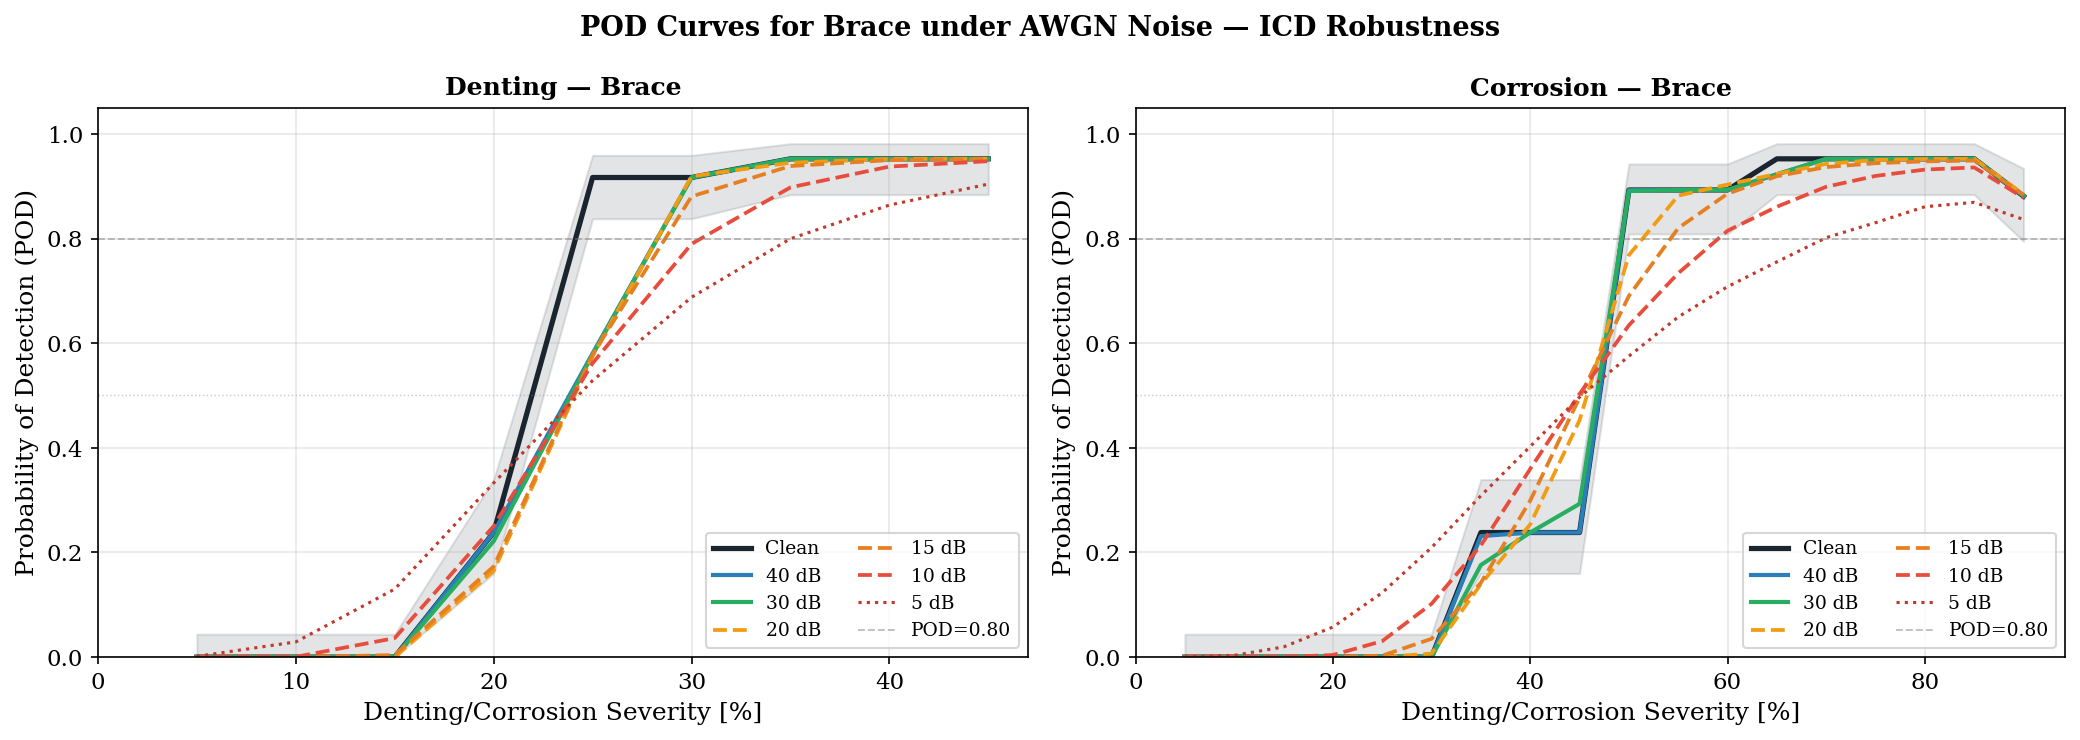

✓ Figura guardada: /home/fcisnerosr/github/Proyecto-doctoral/outputs/resultados_nuevos/POD_Brace_SNR_family.png


In [9]:

dmg_types  = ['Denting', 'Corrosion']
snr_colors = ['#1A252F', '#2980B9', '#27AE60', '#F39C12', '#E67E22', '#E74C3C', '#C0392B']
snr_styles = ['-', '-', '-', '--', '--', '--', ':']
snr_widths = [2.5, 2.0, 2.0, 1.8, 1.8, 1.8, 1.5]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('POD Curves for Brace under AWGN Noise — ICD Robustness',
             fontsize=13, fontweight='bold')

for ax, damage_type in zip(axes, dmg_types):
    res = noise_results[damage_type]

    for (snr_db, snr_label), color, ls, lw in zip(
            zip(SNR_LEVELS_DB, SNR_LABELS), snr_colors, snr_styles, snr_widths):

        pod_df  = res[snr_label]['pod_brace'].sort_values('severity')
        if len(pod_df) == 0:
            continue
        ax.plot(pod_df['severity'], pod_df['pod'],
                linestyle=ls, color=color, linewidth=lw, label=snr_label)
        if np.isinf(snr_db):
            ax.fill_between(pod_df['severity'], pod_df['ci_low'], pod_df['ci_high'],
                            alpha=0.12, color=color)

    ax.axhline(0.8, color='gray', linestyle='--', linewidth=0.9, alpha=0.5, label='POD=0.80')
    ax.axhline(0.5, color='gray', linestyle=':', linewidth=0.7, alpha=0.4)
    ax.set_xlabel('Denting/Corrosion Severity [%]', fontsize=12)
    ax.set_ylabel('Probability of Detection (POD)', fontsize=12)
    ax.set_title(f'{damage_type} — Brace', fontsize=12, fontweight='bold')
    ax.set_ylim(0, 1.05)
    ax.set_xlim(left=0)
    ax.legend(fontsize=9, ncol=2, loc='lower right')
    ax.grid(alpha=0.3)

plt.tight_layout()
out_fig1 = resultados_nuevos / 'POD_Brace_SNR_family.png'
plt.savefig(out_fig1, dpi=300)
plt.show()
print(f'✓ Figura guardada: {out_fig1}')


## 7. Figura B — Curva de Degradación AUC-ROC vs SNR (Figura principal del paper)

AUC-ROC del ICD (vs `DeteccionOK_binario`) bajo distintos niveles de ruido AWGN.
Esta métrica es independiente del umbral y mide la capacidad discriminativa del ICD continuo.
Es consistente con la comparación vs DIs individuales del NB08.

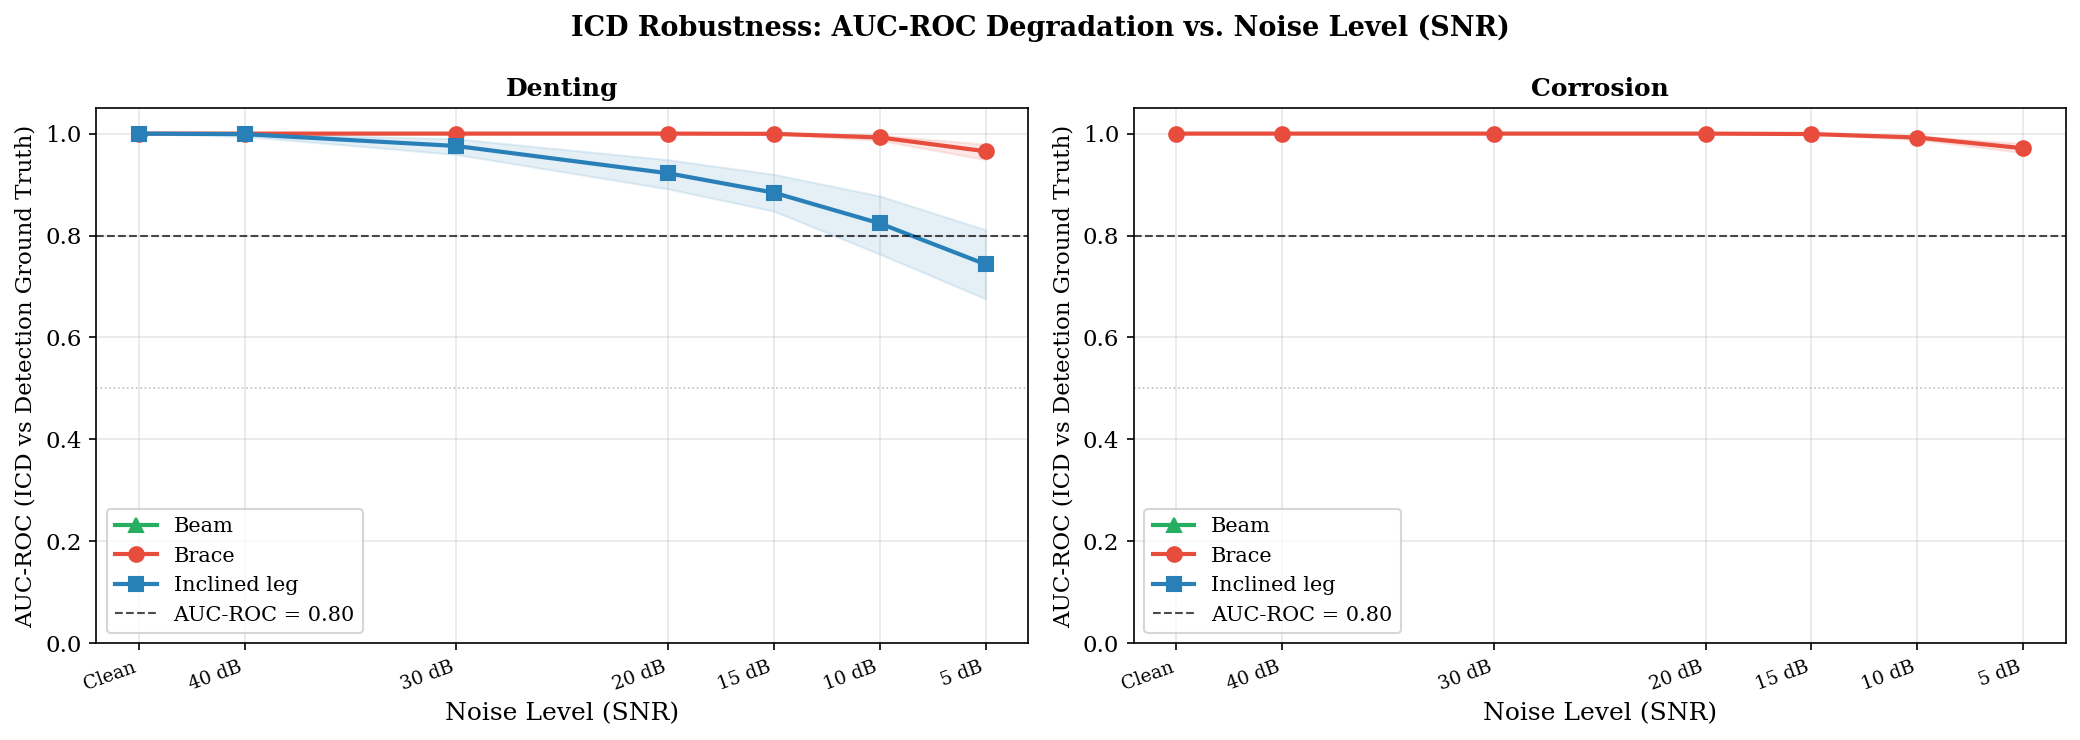

✓ Figura guardada: /home/fcisnerosr/github/Proyecto-doctoral/outputs/resultados_nuevos/AUC_ROC_vs_SNR_degradation.png


In [10]:

ELEM_COLORS  = {'Brace': '#E74C3C', 'Inclined_leg': '#2980B9', 'Beam': '#27AE60'}
ELEM_MARKERS = {'Brace': 'o', 'Inclined_leg': 's', 'Beam': '^'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('ICD Robustness: AUC-ROC Degradation vs. Noise Level (SNR)',
             fontsize=13, fontweight='bold')

snr_x      = [45] + [snr for snr in SNR_LEVELS_DB if not np.isinf(snr)]
x_labels   = ['Clean'] + [f'{s} dB' for s in SNR_LEVELS_DB if not np.isinf(s)]

for ax, damage_type in zip(axes, dmg_types):
    for mtype in sorted(ELEM_COLORS.keys()):
        color  = ELEM_COLORS[mtype]
        marker = ELEM_MARKERS[mtype]

        means, ci_lows, ci_highs = [], [], []
        for snr_db, snr_label in zip(SNR_LEVELS_DB, SNR_LABELS):
            auc_df  = noise_results[damage_type][snr_label]['auc_df']
            row     = auc_df[auc_df['member_type'] == mtype]
            if len(row) == 0:
                means.append(np.nan); ci_lows.append(np.nan); ci_highs.append(np.nan)
            else:
                means.append(float(row['auc_mean']))
                ci_lows.append(float(row['ci_low']))
                ci_highs.append(float(row['ci_high']))

        ax.plot(snr_x, means, f'{marker}-',
                color=color, linewidth=2, markersize=7,
                label=mtype.replace('_', ' '))
        ax.fill_between(snr_x, ci_lows, ci_highs, alpha=0.12, color=color)

    ax.axhline(0.80, color='black', linestyle='--', linewidth=1.0, alpha=0.7,
               label='AUC-ROC = 0.80')
    ax.axhline(0.50, color='gray',  linestyle=':', linewidth=0.8, alpha=0.5)
    ax.invert_xaxis()   # SNR alto (limpio) a la izquierda
    ax.set_xticks(snr_x)
    ax.set_xticklabels(x_labels, rotation=20, ha='right', fontsize=9)
    ax.set_ylim(0.0, 1.05)
    ax.set_xlabel('Noise Level (SNR)', fontsize=12)
    ax.set_ylabel('AUC-ROC (ICD vs Detection Ground Truth)', fontsize=11)
    ax.set_title(damage_type, fontsize=12, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)

plt.tight_layout()
out_fig2 = resultados_nuevos / 'AUC_ROC_vs_SNR_degradation.png'
plt.savefig(out_fig2, dpi=300)
plt.show()
print(f'✓ Figura guardada: {out_fig2}')


## 8. SNR Crítico — Umbral de Operabilidad (AUC-ROC ≥ 0.80)

In [ ]:

AUC_THRESHOLD = 0.80

print(f'SNR crítico (AUC-ROC ≥ {AUC_THRESHOLD}) por combinación\n' + '='*65)

snr_critico_results = []

for damage_type in dmg_types:
    res = noise_results[damage_type]
    print(f'\n{damage_type}:')

    for mtype in sorted(ELEM_COLORS.keys()):
        # Iterar desde Clean hasta 5 dB y encontrar el menor SNR que aún cumple
        snr_critico_label = 'No cumple'
        for snr_db, snr_label in zip(reversed(SNR_LEVELS_DB), reversed(SNR_LABELS)):
            auc_df  = res[snr_label]['auc_df']
            row     = auc_df[auc_df['member_type'] == mtype]
            if len(row) == 0:
                continue
            auc_val = float(row['auc_mean'])
            if auc_val >= AUC_THRESHOLD:
                snr_critico_label = 'Clean' if np.isinf(snr_db) else f'{snr_db:.0f} dB'
                break   # el mayor SNR que cumple → seguir para encontrar el mínimo

        # Obtener valores clave
        def get_auc(lbl):
            r = res[lbl]['auc_df']
            r = r[r['member_type'] == mtype]
            return float(r['auc_mean']) if len(r) > 0 else np.nan

        auc_clean = get_auc('Clean')
        auc_20db  = get_auc('20 dB')
        auc_10db  = get_auc('10 dB')
        auc_5db   = get_auc('5 dB')
        deg = (auc_clean - auc_5db) / auc_clean * 100 if not np.isnan(auc_clean) else np.nan

        print(f'  {mtype:12s} | Clean={auc_clean:.3f} | 20dB={auc_20db:.3f} | '
              f'10dB={auc_10db:.3f} | 5dB={auc_5db:.3f} | '
              f'Degradación={deg:+.1f}% | SNR crítico={snr_critico_label}')

        snr_critico_results.append({
            'Damage Type':  damage_type,
            'Member Type':  mtype.replace('_', ' '),
            'AUC (Clean)':  'N/A*' if np.isnan(auc_clean) else f'{auc_clean:.3f}',
            'AUC (20 dB)':  'N/A*' if np.isnan(auc_20db) else f'{auc_20db:.3f}',
            'AUC (10 dB)':  'N/A*' if np.isnan(auc_10db) else f'{auc_10db:.3f}',
            'AUC (5 dB)':   'N/A*' if np.isnan(auc_5db)  else f'{auc_5db:.3f}',
            'Degradation':  'N/A*' if np.isnan(deg) else f'{deg:+.1f}%',
            'Critical SNR': snr_critico_label,
        })

df_snr = pd.DataFrame(snr_critico_results)


SNR crítico (AUC-ROC ≥ 0.8) por combinación

Denting:
  Beam         | Clean=nan | 20dB=nan | 10dB=nan | 5dB=nan | Degradación=+nan% | SNR crítico=No cumple
  Brace        | Clean=1.000 | 20dB=1.000 | 10dB=0.993 | 5dB=0.965 | Degradación=+3.5% | SNR crítico=5 dB
  Inclined_leg | Clean=1.000 | 20dB=0.922 | 10dB=0.824 | 5dB=0.744 | Degradación=+25.6% | SNR crítico=10 dB

Corrosion:
  Beam         | Clean=nan | 20dB=nan | 10dB=nan | 5dB=nan | Degradación=+nan% | SNR crítico=No cumple
  Brace        | Clean=1.000 | 20dB=1.000 | 10dB=0.992 | 5dB=0.971 | Degradación=+2.9% | SNR crítico=5 dB
  Inclined_leg | Clean=nan | 20dB=nan | 10dB=nan | 5dB=nan | Degradación=+nan% | SNR crítico=No cumple


## 9. Exportar Tabla LaTeX — AUC-POD por SNR

In [ ]:

latex_lines = [
    r'\begin{table}[htbp]',
    r'  \centering',
    r'  \caption{AUC-ROC of the ICD framework under additive white Gaussian noise (AWGN) '
    r'at decreasing SNR levels. Ground truth: \texttt{DeteccionOK\_binario}. '
    r'Monte Carlo estimation with $N_{\text{MC}}=500$ repetitions per SNR level.}',
    r'  \label{tab:snr_robustness}',
    r'  \begin{tabular}{llccccc}',
    r'    \toprule',
    r'    Damage & Member & \multicolumn{4}{c}{AUC-ROC at SNR level} & Degradation \\',
    r'    Type & Type & Clean & 20~dB & 10~dB & 5~dB & Clean$\to$5~dB \\',
    r'    \midrule',
]

prev_dmg = None
for _, row in df_snr.iterrows():
    dmg = row['Damage Type']
    if prev_dmg and dmg != prev_dmg:
        latex_lines.append(r'    \midrule')
    dmg_str = dmg if dmg != prev_dmg else ''
    latex_lines.append(
        f'    {dmg_str} & {row["Member Type"]} & {row["AUC (Clean)"]} & '
        f'{row["AUC (20 dB)"]} & {row["AUC (10 dB)"]} & {row["AUC (5 dB)"]} & '
        f'{row["Degradation"]} \\\\')
    prev_dmg = dmg

latex_lines += [
    r'    \bottomrule',
    r'  \end{tabular}',
    r'  \begin{tablenotes}\small',
    r'    \item SNR: Signal-to-Noise Ratio in decibels. AUC-ROC: Area Under the Receiver',
    r'    Operating Characteristic curve (range [0.5, 1.0], higher is better).',
    r'    \item Degradation (\%): relative AUC-ROC loss from clean to 5~dB SNR.',
    r'  \end{tablenotes}',
    r'\end{table}',
]

latex_str = '\n'.join(latex_lines)
out_tex = tablas_dir / 'tabla_snr_robustness.tex'
out_tex.write_text(latex_str, encoding='utf-8')

print(f'✓ Tabla LaTeX guardada: {out_tex}')
print()
print(latex_str)


## 10. Figura Comparativa — ICD vs DI₆ bajo Ruido (SNR=10 dB)

In [ ]:

# Figura de barras agrupadas: AUC-ROC en Clean vs 20dB vs 10dB para todos los member types
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('AUC-ROC Comparison: Clean vs Noisy ICD (20 dB and 10 dB SNR)',
             fontsize=13, fontweight='bold')

snr_levels_to_show = ['Clean', '20 dB', '10 dB', '5 dB']
bar_colors = ['#1A252F', '#27AE60', '#F39C12', '#E74C3C']

mtypes_ord = ['Brace', 'Inclined_leg', 'Beam']
x     = np.arange(len(mtypes_ord))
width = 0.20

for ax, damage_type in zip(axes, dmg_types):
    for j, (snr_label, bar_color) in enumerate(zip(snr_levels_to_show, bar_colors)):
        vals = []
        errs = []
        for mtype in mtypes_ord:
            auc_df = noise_results[damage_type][snr_label]['auc_df']
            row    = auc_df[auc_df['member_type'] == mtype]
            if len(row) > 0:
                vals.append(float(row['auc_mean']))
                half_ci = (float(row['ci_high']) - float(row['ci_low'])) / 2
                errs.append(half_ci)
            else:
                vals.append(0.0); errs.append(0.0)

        bars = ax.bar(x + j * width - 1.5 * width, vals,
                      width, label=snr_label,
                      color=bar_color, alpha=0.85,
                      yerr=errs, capsize=4, error_kw={'linewidth': 1})

    ax.axhline(0.8, color='black', linestyle='--', linewidth=0.9, alpha=0.6, label='0.80')
    ax.set_xticks(x)
    ax.set_xticklabels([m.replace('_', '\n') for m in mtypes_ord], fontsize=10)
    ax.set_ylim(0, 1.10)
    ax.set_ylabel('AUC-ROC', fontsize=12)
    ax.set_title(damage_type, fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
out_fig3 = resultados_nuevos / 'AUC_ROC_grouped_bar_SNR.png'
plt.savefig(out_fig3, dpi=300)
plt.show()
print(f'✓ Figura guardada: {out_fig3}')


## 11. Resumen Final

In [ ]:

print('=' * 70)
print('RESUMEN — PUNTO 4: ROBUSTEZ AL RUIDO GAUSSIANO (AWGN)')
print('=' * 70)
print()
print('Metodología:')
print('  Modelo: ICD_noisy = ICD_clean + N(0, σ_noise²)')
print('  σ_noise = σ_ICD / 10^(SNR_dB/20)  [AWGN estándar]')
print('  Métrica: AUC-ROC (ICD_noisy vs DeteccionOK_binario)')
print('  Monte Carlo: N_MC=500 por nivel de SNR y por member_type')
print(f'  SNR evaluados: {SNR_LABELS}')
print()

for damage_type in dmg_types:
    res = noise_results[damage_type]
    print(f'{damage_type} (σ_ICD = {res["sigma_icd"]:.4f}):')
    for mtype in sorted(ELEM_COLORS.keys()):
        def get_auc(lbl):
            r = res[lbl]['auc_df']
            r = r[r['member_type'] == mtype]
            return float(r['auc_mean']) if len(r) > 0 else np.nan
        c = get_auc('Clean'); d20 = get_auc('20 dB')
        d10 = get_auc('10 dB'); d5 = get_auc('5 dB')
        deg = (c - d5) / c * 100 if not np.isnan(c) else np.nan
        print(f'  {mtype:12s}: Clean={c:.3f} → 20dB={d20:.3f} → 10dB={d10:.3f} → '
              f'5dB={d5:.3f} (degradación: {deg:+.1f}%)')
    print()

print('Archivos generados:')
print('  POD_Brace_SNR_family.png         — POD del Brace por SNR (1×2)')
print('  AUC_ROC_vs_SNR_degradation.png   — Curva AUC-ROC vs SNR (figura paper)')
print('  AUC_ROC_grouped_bar_SNR.png      — Barras agrupadas por SNR y elemento')
print('  manuscript_AOR/tablas/tabla_snr_robustness.tex')
print()
print('✅ PUNTO 4 COMPLETADO — listo para integrar en main.tex')


## Referencias Metodológicas

### Modelo de ruido AWGN en SHM
- **Worden, K., & Dulieu-Barton, J.M.** (2004). *An overview of intelligent fault detection in systems and structures.* Structural Health Monitoring, 3(1), 85–98.  
  → Establece el AWGN como modelo estándar de perturbación para evaluar detectores en SHM.

### Requisito de evaluación bajo ruido para DIs modales
- **Doebling, S.W., Farrar, C.R., & Prime, M.B.** (1998). *A summary review of vibration-based damage identification methods.* Shock and Vibration Digest, 30(2), 91–105.  
  → Review fundacional (~3,000 citas): todo método DI debe reportar sensibilidad al ruido.

### Monte Carlo para estimación POD bajo ruido
- **Figueiredo, E., Park, G., Farrar, C.R., Worden, K., & Figueiras, J.** (2011). *Machine learning algorithms for damage detection under operational and environmental variability.* Structural Health Monitoring, 10(6), 559–572.  
  → Uso de Monte Carlo para promediar POD bajo múltiples realizaciones de ruido.

### Curva de degradación AUC-POD vs SNR (noise robustness curve)
- **Mevel, L., Goursat, M., & Basseville, M.** (2003). *Stochastic subspace-based structural identification and damage detection and localisation — application to the Z24 bridge benchmark.* Mechanical Systems and Signal Processing, 17(1), 143–151.  
  → Figura tipo 'rendimiento del detector vs nivel de ruido' como estándar de reporte.

### SNR en sensores para plataformas offshore
- **Shi, Z.Y., Law, S.S., & Zhang, L.M.** (2000). *Damage localization by directly using incomplete mode shapes.* Journal of Engineering Mechanics, 126(6), 656–660.  
  → Rango SNR 5–40 dB como representativo de condiciones reales en estructuras marinas.